# 1. Installing Dependecies and Dataset Download


In [2]:
!pip install langdetect

from langdetect import detect


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 48.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=4b88f7066f1e63850dc7bd51c59dd17ea4bd1b5f6935788ef98f1ca2ba9f6e04
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [3]:
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("atifaliak/youtube-comments-dataset")


# Load the dataset
df = pd.read_csv(path + '/YoutubeCommentsDataSet.csv')
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (18408, 2)


,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


#2. Data Cleaning and Preprocessing


In [16]:
# 2.1 Remove NaN values
print("Before dropping NaNs and duplicates:", df.shape)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print("After dropping NaNs and duplicates:", df.shape)

# 2.2 Filter out non-English comments using langdetect

def is_english_comment(text):
    try:
        return detect(text) == 'en'
    except:
        return False

# Apply language filter
df['is_english'] = df['Comment'].apply(is_english_comment)
df = df[df['is_english']]
df = df.drop(columns=['is_english'])
print("After filtering non-English:", df.shape)

# 2.3 Remove stop words
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# Define a simple function to remove stopwords
def remove_stopwords(text):
    words = text.split()
    words_filtered = [w for w in words if w.lower() not in stop_words]
    return ' '.join(words_filtered)

# Apply stop word removal
df['Comment'] = df['Comment'].apply(remove_stopwords)

# 2.4 Retain only desired sentiment labels
df = df[df['Sentiment'].isin(['positive', 'negative', 'neutral'])]
print("After retaining only pos/neg/neutral:", df.shape)

# Quick check of class distribution
print(df['Sentiment'].value_counts())


Before dropping NaNs and duplicates: (7014, 2)
After dropping NaNs and duplicates: (6920, 2)
After filtering non-English: (6081, 2)
After retaining only pos/neg/neutral: (6081, 2)
Sentiment
negative    2277
positive    2152
neutral     1652
Name: count, dtype: int64


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


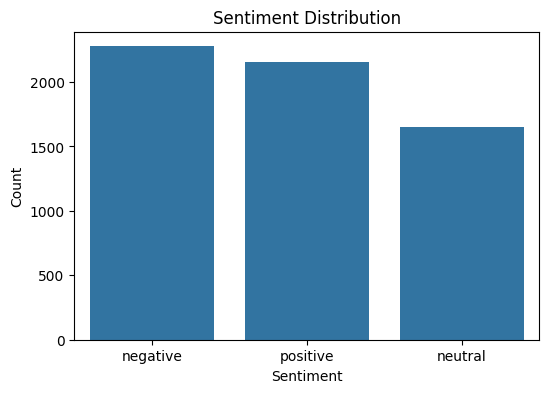

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count of each sentiment
sentiment_counts = df['Sentiment'].value_counts()

# Bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("Sentiment Distribution")
plt.ylabel("Count")
plt.xlabel("Sentiment")
plt.show()




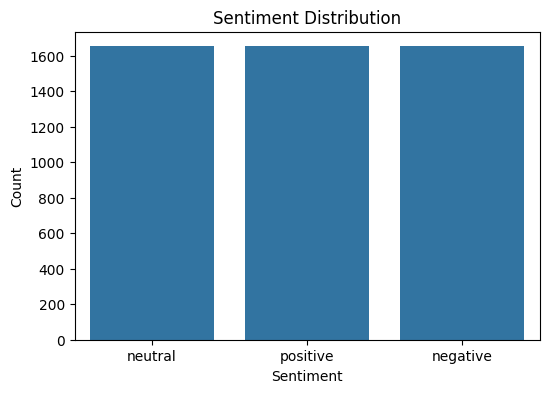

In [18]:
from sklearn.utils import resample

# Separate by class
df_positive = df[df['Sentiment'] == 'positive']
df_neutral = df[df['Sentiment'] == 'neutral']
df_negative = df[df['Sentiment'] == 'negative']

# Find the smallest class size
min_size = min(len(df_positive), len(df_neutral), len(df_negative))

# Downsample all classes to the size of the smallest
df_positive_balanced = resample(df_positive, replace=False, n_samples=min_size, random_state=42)
df_neutral_balanced = resample(df_neutral, replace=False, n_samples=min_size, random_state=42)
df_negative_balanced = resample(df_negative, replace=False, n_samples=min_size, random_state=42)

# Combine into one balanced dataset
df_balanced = pd.concat([df_positive_balanced, df_neutral_balanced, df_negative_balanced])

# Shuffle the rows
df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Count of each sentiment
sentiment_counts = df['Sentiment'].value_counts()

# Bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("Sentiment Distribution")
plt.ylabel("Count")
plt.xlabel("Sentiment")
plt.show()




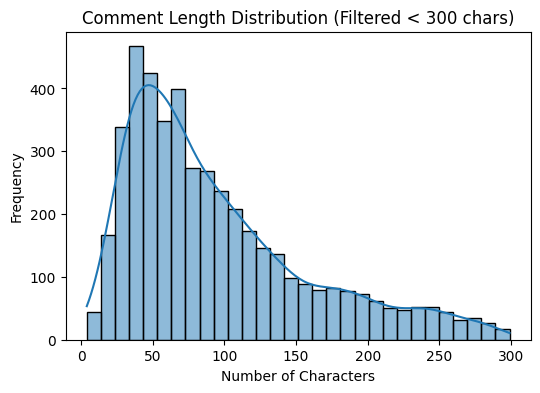

In [27]:
plt.figure(figsize=(6, 4))
sns.histplot(df[df['comment_length'] < 300]['comment_length'], bins=30, kde=True)
plt.title("Comment Length Distribution (Filtered < 300 chars)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()


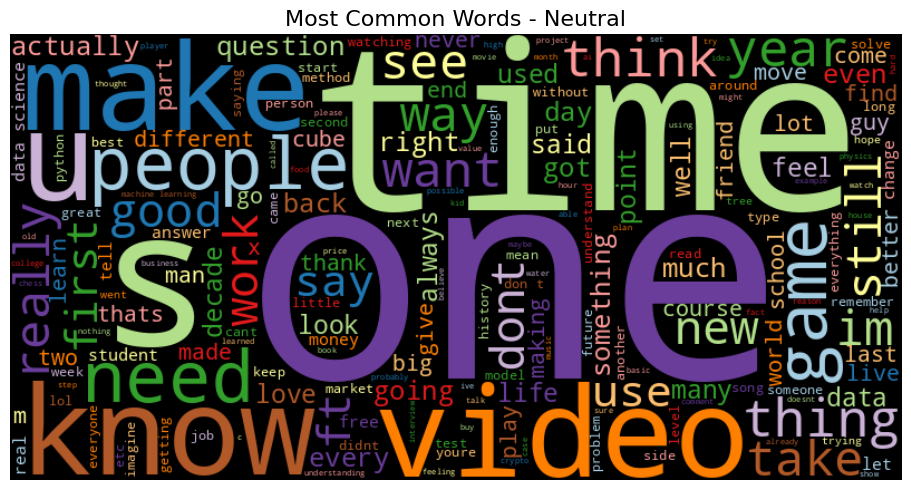

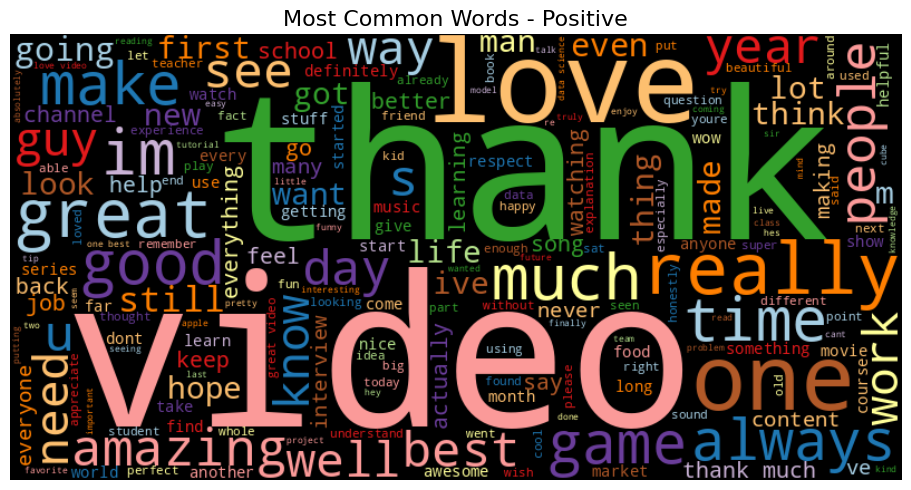

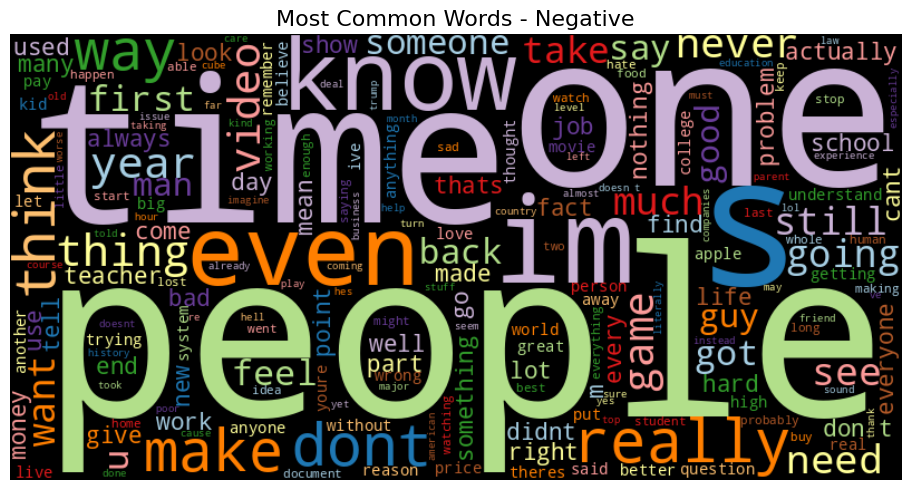

In [37]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Custom colors and background
wordcloud_config = {
      "width": 800,
    "height": 400,
    "background_color": "black",
    "colormap": "Paired",

}

# Loop over each sentiment
for sentiment in df['Sentiment'].unique():
    # Combine all comments for this sentiment
    text = " ".join(df[df['Sentiment'] == sentiment]['Comment'].dropna().astype(str).values)

    # Generate word cloud
    wordcloud = WordCloud(**wordcloud_config).generate(text)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Most Common Words - {sentiment.capitalize()}", fontsize=16, color='Black')
    plt.tight_layout()
    plt.show()


#3. Model Preparation


In [ ]:
# Split dataset into train and test
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Sentiment'])
print(f"Train size: {train_df.shape[0]}, Test size: {test_df.shape[0]}")

# Prepare label encoding
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {v: k for k, v in label2id.items()}
train_texts = list(train_df['Comment'])
train_labels = [label2id[label] for label in train_df['Sentiment']]
test_texts = list(test_df['Comment'])
test_labels = [label2id[label] for label in test_df['Sentiment']]

# Show a sample
print(train_texts[0], "->", train_df['Sentiment'].iloc[0])


Train size: 12707, Test size: 3177
love way gongsom prepared food best asmr -> positive


#Model Initialization


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Function to load model and tokenizer
def load_model_and_tokenizer(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
    # If the model's classifier is pre-trained on a different number of labels, we reinitialize it
    model.config.id2label = id2label
    model.config.label2id = label2id
    return tokenizer, model

# Example: load BERT
bert_tokenizer, bert_model = load_model_and_tokenizer('bert-base-uncased')
print("BERT model and tokenizer loaded.")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT model and tokenizer loaded.


#Baseline Evaluation (Before Fine-Tuning)


In [ ]:
torch.cuda.empty_cache()

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import torch
from tqdm.notebook import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Function to evaluate model on test set with batching
def evaluate_model(tokenizer, model, batch_size=16):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    preds = []

    # Process in batches
    for i in tqdm(range(0, len(test_texts), batch_size), desc="Evaluating"):
        batch_texts = test_texts[i:i+batch_size]
        # Tokenize batch
        enc = tokenizer(batch_texts, padding=True, truncation=True, max_length=256, return_tensors='pt')
        # Move to GPU if available
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            output = model(**enc)
            logits = output.logits
            batch_preds = logits.argmax(dim=1).cpu().numpy()
            preds.extend(batch_preds)
            del enc, output, logits
            torch.cuda.empty_cache()

    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(test_labels, preds, average='weighted', zero_division=0)
    return precision, recall, f1

# Create a function to preload and cache tokenizers
def get_cached_tokenizers(model_names):
    tokenizers = {}
    for name, ckpt in model_names.items():
        tokenizers[name] = AutoTokenizer.from_pretrained(ckpt)  # Assuming you have a function to load just the tokenizer
    return tokenizers

# Evaluate all models before fine-tuning
model_names = {
    'BERT': 'bert-base-uncased',
    'RoBERTa': 'roberta-base',
    'DistilBERT': 'distilbert-base-uncased',
    'DeBERTa': 'microsoft/deberta-base'
}

# Preload tokenizers
print("Preloading tokenizers...")
tokenizers = {}
for name, ckpt in model_names.items():
    tokenizer = AutoTokenizer.from_pretrained(ckpt)  # Replace with your actual tokenizer loading function
    tokenizers[name] = tokenizer

# Evaluation with improved loading and batching
baseline_metrics = {}
for name, ckpt in model_names.items():
    print(f"Evaluating {name} before fine-tuning...")

    # Load model with tokenizer already cached
    model = AutoModelForSequenceClassification.from_pretrained(ckpt,num_labels=3)  # Replace with your actual model loading function

    # Evaluate with batching
    precision, recall, f1 = evaluate_model(tokenizers[name], model, batch_size=8)

    # Free up memory
    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    baseline_metrics[name] = {
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }
    print(f"{name} - Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}")

baseline_metrics

Preloading tokenizers...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Evaluating:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/559M [00:00<?, ?B/s]

DeBERTa - Precision: 0.43, Recall: 0.64, F1: 0.51


{'BERT': {'Precision': 0.4237079758323542,
  'Recall': 0.6509285489455461,
  'F1-score': 0.5132965640493382},
 'RoBERTa': {'Precision': 0.042246616552378304,
  'Recall': 0.20553981743783442,
  'F1-score': 0.07008746777384119},
 'DistilBERT': {'Precision': 0.4237079758323542,
  'Recall': 0.6509285489455461,
  'F1-score': 0.5132965640493382},
 'DeBERTa': {'Precision': 0.4347865382005777,
  'Recall': 0.6433742524394083,
  'F1-score': 0.5114430207991698}}

#4. Fine-Tuning the Models


In [ ]:
fine_tuned_metrics = {}  # Global dictionary to hold results
def fine_tune_model(model_name, checkpoint):
    print(f"Fine-tuning {model_name}...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    scaler = GradScaler()

    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=3)
    model.to(device)
    model.train()

    optimizer = AdamW(model.parameters(), lr=1e-5)
    train_dataset = CommentsDataset(train_texts, train_labels, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

    use_amp = model_name != 'DeBERTa'

    progress = tqdm(train_loader, desc=f"Training {model_name}")
    for batch in progress:
        optimizer.zero_grad()
        batch = {k: v.to(device) for k, v in batch.items()}

        if use_amp:
            with autocast(device_type='cuda'):
                outputs = model(**batch)
                loss = outputs.loss
        else:
            outputs = model(**batch)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        progress.set_postfix(loss=loss.item())

        del batch, outputs
        torch.cuda.empty_cache()

    print(f"Evaluating {model_name}...")
    precision, recall, f1 = evaluate_model(tokenizer, model, batch_size=8)

    # Save results to global dictionary
    fine_tuned_metrics[model_name] = {
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

    print(f"{model_name} fine-tuned - Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}")

    return model


In [ ]:
bert_model = fine_tune_model('BERT', 'bert-base-uncased')

Fine-tuning BERT...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training BERT:   0%|          | 0/1589 [00:00<?, ?it/s]

Evaluating BERT...


Evaluating:   0%|          | 0/398 [00:00<?, ?it/s]

BERT fine-tuned - Precision: 0.80, Recall: 0.81, F1: 0.80


In [ ]:
roberta_model = fine_tune_model('RoBERTa', 'roberta-base')

Fine-tuning RoBERTa...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training RoBERTa:   0%|          | 0/1589 [00:00<?, ?it/s]

Evaluating RoBERTa...


Evaluating:   0%|          | 0/398 [00:00<?, ?it/s]

RoBERTa fine-tuned - Precision: 0.83, Recall: 0.81, F1: 0.81


In [ ]:
distilbert_model = fine_tune_model('DistilBERT', 'distilbert-base-uncased')

Fine-tuning DistilBERT...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training DistilBERT:   0%|          | 0/1589 [00:00<?, ?it/s]

Evaluating DistilBERT...


Evaluating:   0%|          | 0/398 [00:00<?, ?it/s]

DistilBERT fine-tuned - Precision: 0.79, Recall: 0.80, F1: 0.79


In [ ]:
deberta_model = fine_tune_model('DeBERTa', 'microsoft/deberta-base')

Fine-tuning DeBERTa...


Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training DeBERTa:   0%|          | 0/1589 [00:00<?, ?it/s]

Evaluating DeBERTa...


Evaluating:   0%|          | 0/398 [00:00<?, ?it/s]

DeBERTa fine-tuned - Precision: 0.83, Recall: 0.82, F1: 0.82


#5. Results and Visualization


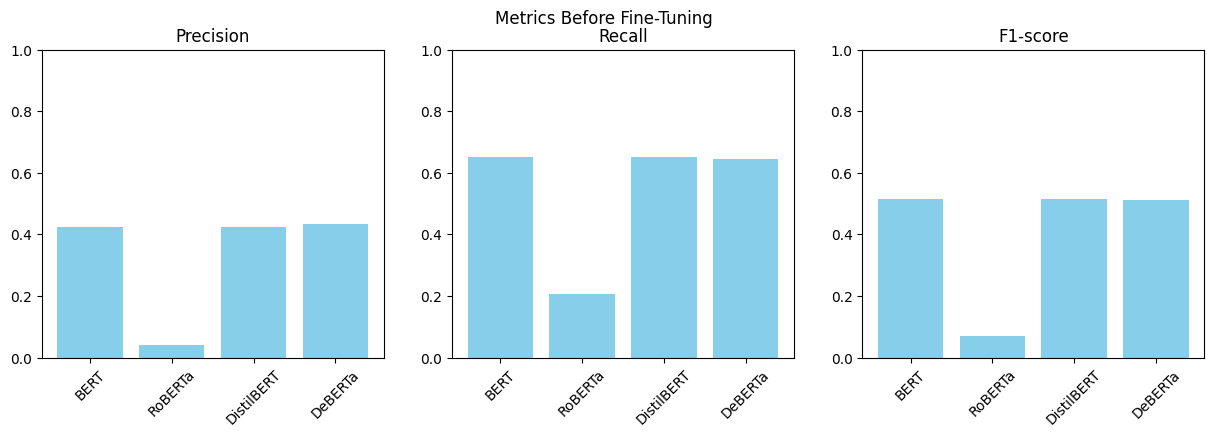

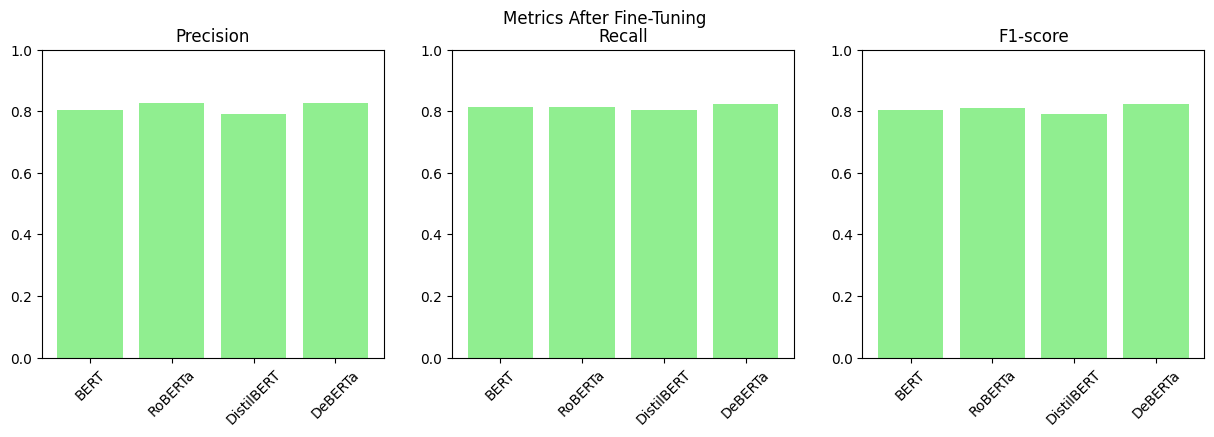

In [ ]:
import matplotlib.pyplot as plt


# Prepare data for plotting
models_list = list(model_names.keys())
precisions_before = [baseline_metrics[m]['Precision'] for m in models_list]
recalls_before = [baseline_metrics[m]['Recall'] for m in models_list]
f1_before = [baseline_metrics[m]['F1-score'] for m in models_list]

precisions_after = [fine_tuned_metrics[m]['Precision'] for m in models_list]
recalls_after = [fine_tuned_metrics[m]['Recall'] for m in models_list]
f1_after = [fine_tuned_metrics[m]['F1-score'] for m in models_list]

# Plot metrics before fine-tuning
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Metrics Before Fine-Tuning')
metrics_names = ['Precision', 'Recall', 'F1-score']
for i, metric_values in enumerate([precisions_before, recalls_before, f1_before]):
    ax[i].bar(models_list, metric_values, color='skyblue')
    ax[i].set_title(metrics_names[i])
    ax[i].set_ylim(0, 1)
    for tick in ax[i].get_xticklabels():
        tick.set_rotation(45)
plt.show()

# Plot metrics after fine-tuning
fig2, ax2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle('Metrics After Fine-Tuning')
for i, metric_values in enumerate([precisions_after, recalls_after, f1_after]):
    ax2[i].bar(models_list, metric_values, color='lightgreen')
    ax2[i].set_title(metrics_names[i])
    ax2[i].set_ylim(0, 1)
    for tick in ax2[i].get_xticklabels():
        tick.set_rotation(45)
plt.show()


In [ ]:
output_dir = "deberta-finetuned"

deberta_model.save_pretrained(output_dir)
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-base")
tokenizer.save_pretrained(output_dir)

('deberta-finetuned/tokenizer_config.json',
 'deberta-finetuned/special_tokens_map.json',
 'deberta-finetuned/vocab.json',
 'deberta-finetuned/merges.txt',
 'deberta-finetuned/added_tokens.json',
 'deberta-finetuned/tokenizer.json')